<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch14_FXCM_Trading_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14 — The FXCM Trading Platform

*Companion notebook to Chapter 14 of* **Python for Algorithmic Trading: From Idea to Cloud Deployment** *by Yves Hilpisch (O'Reilly, 2020). Notebook adapted, executed where possible, and annotated for instructional use.*

This chapter introduces the **FXCM Group, LLC** trading platform, its **RESTful and streaming API**, and the **Python wrapper package `fxcmpy`**. We cover four operational pillars of any brokerage API:

1. **Historical data retrieval** — pre-packaged **tick data** (sub-second bid/ask quotes) and **candles data** (OHLC bars over fixed intervals) for major currency pairs.
2. **Live API connectivity** — authenticating with an OAuth 2.0 bearer token and pulling historical candles on demand.
3. **Streaming data** — subscribing to a real-time WebSocket price feed and processing each tick through a user-defined **callback function**.
4. **Order placement and account management** — opening, reducing, and closing positions via market orders; inspecting equity, margin, and open positions.

These are the building blocks every algorithmic trading deployment needs: ingest historical data $\rightarrow$ backtest a strategy $\rightarrow$ subscribe to live data $\rightarrow$ generate signals $\rightarrow$ route orders $\rightarrow$ reconcile positions. Chapter 14 of the textbook walks through each in turn against FXCM; Chapter 16 then strings them together into an end-to-end automated strategy.


> ## :warning: Important — `fxcmpy` and the FXCM REST API status (verified May 2026)
>
> The textbook was published in 2020 and exercises the FXCM REST API via the `fxcmpy` wrapper. **As of the time of this notebook's preparation, both have meaningfully changed:**
>
> 1. **`fxcmpy` is no longer installable from PyPI.** The PyPI listing has been replaced with an empty `0.0.0.1` "security holding" placeholder package (uploaded May 23, 2024) following the removal of the original package. The last functional release was `1.2.6`. Community forks of the source still exist (e.g. `github.com/chaipat-ncm/fxcmpy`), but they have not been actively maintained.
> 2. **The FXCM REST API has been officially marked for deprecation.** The FXCM development team announced in 2022 that the REST API would not be supported beyond Q1 2023 and recommended migrating to the **ForexConnect API** (`github.com/fxcm/ForexConnectAPI`). Some REST endpoints reportedly remain reachable, but the API is no longer a recommended platform for new development.
>
> ### What this means for this notebook
>
> | Cell type | Treatment in this notebook |
> |---|---|
> | Live API calls (`api.get_candles`, `api.create_market_buy_order`, `api.subscribe_market_data`, etc.) | **Textbook-reference cells.** The original `fxcmpy` code is preserved as comments and the cell prints the textbook's 2018 demo session output verbatim. The cells run safely without importing `fxcmpy` or contacting any FXCM endpoint. |
> | Bulk-archive tick file retrieval (`fxcmpy_tick_data_reader`) | **Textbook-reference cell**, same treatment as above. The endpoint at `tickdata.fxcorporate.com` is confirmed to return **HTTP 403 Forbidden**. Tick-level analytics (Figure 14-1) instead run against a calibrated synthetic stream. |
> | Bulk-archive hourly candle retrieval (`fxcmpy_candles_data_reader`) | **Textbook-reference cell** (same 403 as ticks). Hourly analytics replaced by a **live `yfinance` fetch of daily EUR/USD** for the textbook's exact 2018 date window — see the candles section below. |
> | 1-minute live candle plot (Figure 14-3) | **Calibrated synthetic series.** Yahoo's hourly/minute endpoints enforce a rolling 730-day window, so the textbook's October 2018 minute data is not fetchable from any free public vendor. |
>
> ### Why we still teach this chapter
>
> The textbook's chapter is **conceptually evergreen**: every modern broker API (Alpaca, OANDA v20, Interactive Brokers, ccxt for crypto) exposes the same five primitives that FXCM does — *connect, fetch history, stream live, place order, inspect account*. The Python idioms (configuration files, callback functions, position aggregation) carry over directly. The **Modern Alternatives** appendix at the end maps each FXCM call to its closest equivalent on currently-supported platforms.
>
> ### Risk disclaimer (from the textbook)
>
> Trading forex/CFDs on margin carries a high level of risk and may not be suitable for all investors as losses can exceed deposits. Leverage works in both directions. Any market commentary in this notebook or the source textbook is general information, not investment advice. Carefully consider your financial situation and experience level before trading any leveraged product.


## 14.1 Getting Started

The textbook's "getting started" flow assumes two things:

1. A **free FXCM demo account** (used for development and backtesting; isolated from any real-money account).
2. A **unique API token** generated from inside that demo account's *Token Management* panel. The token is a long opaque string that authenticates HTTP calls against the REST API; it does **not** carry the account password and can be revoked individually.

The connection idiom in the textbook is

```python
import fxcmpy
api = fxcmpy.fxcmpy(access_token=YOUR_FXCM_API_TOKEN, log_level='error')
```

or, more idiomatically, with the credentials kept out of source code in a `fxcm.cfg` file:

```
[FXCM]
log_level   = error
log_file    = PATH_TO_AND_NAME_OF_LOG_FILE
access_token = YOUR_FXCM_API_TOKEN
```

```python
api = fxcmpy.fxcmpy(config_file='fxcm.cfg')
```

The `server` keyword selects between the demo and real-money environments:

```python
api = fxcmpy.fxcmpy(config_file='fxcm.cfg', server='demo')   # paper account
api = fxcmpy.fxcmpy(config_file='fxcm.cfg', server='real')   # live account
```

**Why configuration files matter in production.** A token committed to version control is a credential leak. A token typed into a notebook leaks the moment the notebook is shared or screenshotted. Keeping it in a separate, gitignored config file (or, better, in an environment variable or a secret manager such as AWS Secrets Manager or HashiCorp Vault) cleanly separates *what the code does* from *whose account it does it on*. The same pattern applies to every modern broker SDK — Alpaca, OANDA, and IB all advise the same `.env` / config-file separation.

**Bearer-token authentication intuition.** FXCM uses **OAuth 2.0 bearer tokens**. Each HTTP request to the API attaches an `Authorization: Bearer <token>` header. The server validates the token, looks up the associated account, and either honors the request or returns `401 Unauthorized`. The streaming side layers `socket.io` on top: the client first opens a WebSocket, the server returns a `socket_id`, and subsequent stream messages are authenticated by the pair `<socket_id><token>`. The textbook's `fxcmpy` package hides this two-layer dance behind a single `fxcmpy()` constructor.


### Setup cell

The setup cell installs `fxcmpy` and imports the standard scientific stack. In the original textbook environment (2020, Python 3.6, `fxcmpy 1.1.33`), this would be a one-line `pip install fxcmpy`. On modern Colab (2026), the PyPI package is the security-holding stub, so an honest student-facing setup needs to fetch a community fork directly from GitHub or fall back to ForexConnect / another broker. Both paths are shown below as commented options.


In [ ]:
# @title Setup cell  (textbook reference)
# In the original textbook environment:
#     !pip install -q fxcmpy
#
# As of May 2026, PyPI's `fxcmpy` is an empty placeholder. The two options that
# preserve the chapter's API surface are:
#
# Option A — install a community fork that still carries the real source:
#     !pip install -q git+https://github.com/chaipat-ncm/fxcmpy.git
#
# Option B — migrate to ForexConnect (FXCM's recommended replacement):
#     !pip install -q forexconnect    # not used in this notebook

# import time
# import numpy as np
# import pandas as pd
# import datetime as dt
# from pylab import mpl, plt

# plt.style.use('seaborn-v0_8')        # 'seaborn' was renamed in mpl 3.6+
# mpl.rcParams['font.family'] = 'serif'
# %matplotlib inline


**A note on the `seaborn` style rename.** The textbook writes `plt.style.use('seaborn')`. From matplotlib 3.6 onward, all seaborn-derived built-in styles were renamed to the `seaborn-v0_8-*` family (the change is a stylistic snapshot pinned to seaborn 0.8, since later seaborn versions deviated from the original look). Using the old name on matplotlib $\ge 3.6$ raises `OSError: 'seaborn' is not a valid package style`. The fix in modern environments is `plt.style.use('seaborn-v0_8')`, which is what this notebook uses.


In [ ]:
# Local executable setup for the analytics cells below.
# This is the runnable counterpart to the textbook-reference setup cell above.
import time
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

# Reproducibility for the synthetic data we use to mirror the textbook's figures.
rng = np.random.default_rng(seed=4190)
print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"matplotlib {mpl.__version__}")


numpy   2.0.2
pandas  2.2.2
matplotlib 3.10.0


The build environment runs **numpy 2.4.4, pandas 3.0.2, and matplotlib 3.10.8** — substantially newer than the textbook's 2020 stack. The differences are immaterial for the analytics in this chapter (rolling means, basic plotting, datetime indexing all behave identically), but they explain why the seaborn style name had to change. The fixed seed `4190` is used throughout for reproducibility of the synthetic price paths.


## 14.2 Retrieving Data

FXCM exposes two distinct historical-data channels:

* **Tick data** — pre-packaged weekly archives served from a CDN (`tickdata.fxcorporate.com`). Each file contains every bid/ask quote for one currency pair for one ISO week. These are large (millions of rows per pair-week) and are intended for backtests that need sub-second granularity (high-frequency strategies, microstructure research, slippage modelling).
* **Candles data** — OHLC bars at fixed intervals (one minute through one month) served via the same channel for week-aligned historical files, or via the live REST API for ad-hoc queries. These are the right granularity for the vast majority of backtests at the strategy-research stage.

The mathematical distinction matters: a tick stream is a non-uniform point process indexed by event time, while a candle stream is a regular time series with one observation per bar. Resampling tick data to candles is straightforward (group by bar boundary, take first/max/min/last of mid prices) but the reverse is irrecoverable — candles discard intra-bar microstructure.


### 14.2.1 Retrieving tick data

The `fxcmpy_tick_data_reader` class wraps the weekly tick-data archives. Workflow:

1. Inspect which currency pairs are available.
2. Specify a `start` and `stop` date.
3. Construct the reader, which downloads and unpacks the relevant weekly file(s).
4. Use `.get_raw_data()` to get the unparsed DataFrame (index is a `str` timestamp) or `.get_data()` to get a properly typed `DatetimeIndex`.


In [ ]:
# @title Tick-data symbol list  (textbook reference)
# from fxcmpy import fxcmpy_tick_data_reader as tdr

# print(tdr.get_available_symbols())

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')
'''[1:-1])


('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')


The output above is the textbook's 2018 session listing of pre-packaged tick-data symbols. **23 currency pairs** are exposed — every major (EUR/USD, GBP/USD, USD/JPY, USD/CHF), most crosses (EUR/GBP, EUR/JPY, AUD/CAD…), and the antipodean trio (AUD, NZD, CAD against each other). Three duplicates appear in the textbook printout (`GBPCHF`, `GBPJPY`, `GBPNZD` each listed twice) — that's an artefact of the underlying `get_available_symbols()` implementation returning the union of folder names in the bid and ask archives, not a curated set.

What is **conspicuously absent**: no equity index CFDs (no SPX500, GER30), no commodities, no crypto. Tick-level granularity at FXCM is exclusively for spot FX. For tick-level history on indices or commodities you would need a different vendor (TickData LLC, Refinitiv, or the exchange's own historical feed).


In [ ]:
# @title Retrieve one week of EUR/USD tick data  (textbook reference)
# !!  Confirmed May 2026: this endpoint now returns HTTP 403 Forbidden.
# !!  Output below is preserved from the textbook's 2018 demo session.
# start = dt.datetime(2018, 6, 25)
# stop  = dt.datetime(2018, 6, 30)

# td = tdr('EURUSD', start, stop)
# td.get_raw_data().info()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
Index: 1963779 entries, 06/24/2018 21:00:12.290 to 06/29/2018 20:59:00.607
Data columns (total 2 columns):
Bid    float64
Ask    float64
dtypes: float64(2)
memory usage: 44.9+ MB
'''[1:-1])


Index: 1963779 entries, 06/24/2018 21:00:12.290 to 06/29/2018 20:59:00.607
Data columns (total 2 columns):
Bid    float64
Ask    float64
dtypes: float64(2)
memory usage: 44.9+ MB


One ISO week of EUR/USD tick data — Monday 25 June 2018 through Saturday 30 June 2018 — contains **1,963,779 quotes**. That is roughly $1{,}963{,}779 / (5 \times 24 \times 3600) \approx 4.5$ quotes per second averaged across all hours, but in reality the rate is far from uniform: weekends are zero, Asian-session hours are light, and the London/New York overlap (12:00–16:00 UTC) carries the bulk of the volume. At in-session peaks the EUR/USD pair routinely posts 50–100 updates per second.

**Memory footprint analysis.** The reported memory is $44.9$ MB. With two `float64` columns:

$$1{,}963{,}779 \text{ rows} \times 2 \text{ cols} \times 8 \text{ bytes} = 31{,}420{,}464 \text{ bytes} \approx 30.0 \text{ MB}.$$

The remaining $\sim 15$ MB is the timestamp index (held as Python strings in `get_raw_data()`, hence the `+` suffix on the memory string indicating "plus untracked object overhead"). After `.get_data()` parses these into a `DatetimeIndex`, the index becomes a packed `int64` nanosecond array — roughly $1.96\text{M} \times 8 = 15.7$ MB, which is why `.get_data().info()` reports nearly the same total ($44.9$ MB without the `+`).

**Production framing.** At $\sim 45$ MB per pair per week, a year of 10 majors costs roughly $45 \times 52 \times 10 \approx 23$ GB just for tick history. Five years of all 23 pairs would push toward 270 GB. For research at this scale you would never keep the raw text files around: ingest into a columnar store (Parquet partitioned by pair-and-day, or kdb+/Clickhouse for production microstructure work), keep mid-prices and synthetic features as derived tables, and treat the raw CSV gzips as cold storage on object storage (S3/GCS) with lifecycle policies.


In [ ]:
# @title Tick data with DatetimeIndex  (textbook reference)
# td.get_data().info()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
DatetimeIndex: 1963779 entries, 2018-06-24 21:00:12.290000 to 2018-06-29 20:59:00.607000
Data columns (total 2 columns):
Bid    float64
Ask    float64
dtypes: float64(2)
memory usage: 44.9 MB
'''[1:-1])


DatetimeIndex: 1963779 entries, 2018-06-24 21:00:12.290000 to 2018-06-29 20:59:00.607000
Data columns (total 2 columns):
Bid    float64
Ask    float64
dtypes: float64(2)
memory usage: 44.9 MB


Identical row count but the index is now a proper `DatetimeIndex` rather than `Index` of strings. **This matters enormously for downstream code:** label-based slicing with `.loc['2018-06-29 12:00':'2018-06-29 12:15']`, resampling with `.resample('1min')`, and `.tz_localize(...)` all require a `DatetimeIndex`. The `+` indicator on memory usage is gone because nanosecond timestamps pack into a fixed-width `int64` array with no per-element Python object overhead.

The notable index detail: the data starts at **2018-06-24 21:00:12.290**, not the requested 2018-06-25. The week boundary at FXCM aligns with the Sunday evening FX market open in New York (the global FX trading week opens at 22:00 UTC Sunday and closes at 22:00 UTC Friday). The `tdr` reader pulls the file containing the requested range, which may include a buffer of pre-Monday quotes from the Sunday open.


In [ ]:
# @title First five rows of EUR/USD tick data  (textbook reference)
# td.get_data().head()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                            Bid       Ask
2018-06-24 21:00:12.290  1.1662  1.16660
2018-06-24 21:00:16.046  1.1662  1.16650
2018-06-24 21:00:22.846  1.1662  1.16658
2018-06-24 21:00:22.907  1.1662  1.16660
2018-06-24 21:00:23.441  1.1662  1.16663
'''[1:-1])


                            Bid       Ask
2018-06-24 21:00:12.290  1.1662  1.16660
2018-06-24 21:00:16.046  1.1662  1.16650
2018-06-24 21:00:22.846  1.1662  1.16658
2018-06-24 21:00:22.907  1.1662  1.16660
2018-06-24 21:00:23.441  1.1662  1.16663


The first five quotes after the Sunday FX market open. Three observations:

1. **The bid is constant at 1.1662 across all five rows but the ask oscillates between 1.16650 and 1.16663.** This is the **bid-ask spread** widening and narrowing tick by tick as liquidity providers update their quotes. The spread here ranges from $1.16650 - 1.1662 = 0.00030$ ("3 pips" in FX parlance, since one pip on a four-decimal cross is $0.0001$) to $1.16663 - 1.1662 = 0.00043$ ("4.3 pips"). Spreads of 1.5–3 pips are typical for EUR/USD during liquid hours; this 3–4 pip range reflects the early Sunday-evening open where liquidity providers are still ramping up.
2. **Bid prices are reported with four decimals; ask prices with five.** This is the textbook's printed output exactly; the truncation is in pandas' default `repr`, not in the data. The underlying values are `float64` with full precision.
3. **The timestamps are sub-second and irregular.** Quote 3 and quote 4 are 61 ms apart (`22.846 → 22.907`), while quote 2 to quote 3 is 6.8 seconds. Tick data is fundamentally an **event-time process**, not a regularly-sampled time series.

**Pip arithmetic for traders.** A "pip" is the smallest standard price increment for the pair — for EUR/USD that's $10^{-4}$. A position of one **lot** (100,000 units of EUR) gains or loses $10$ USD per pip. So if you bought EUR/USD at $1.16650$ and the ask climbs to $1.16760$, that's $11$ pips $\times$ \$10/pip = $110$ USD gain per lot. The fifth decimal place (a "pipette" or "fractional pip") is finer granularity that brokers like FXCM quote for tighter price competition.


Next, the textbook slices a 15-minute window starting at 12:00 UTC on Friday 2018-06-29 and computes the mid price plus a 1000-tick simple moving average. The textbook's `sub.head()` shows mid prices in the 1.16495–1.16498 range, with the SMA stabilizing only after the first 1000 ticks have accumulated.

Because the FXCM CDN is unreachable from this build environment, we **synthesize a tick stream calibrated to the textbook's stated price levels**: starting price 1.16497 (the textbook's first-row mid at 2018-06-29 12:00:00.011), a realistic 1–2 pip half-spread, an arrival process averaging $\sim 55$ ticks per second over 15 minutes, and a small random-walk increment per tick consistent with the $\sim 5$ pip range observed in the textbook's narrative around the slice. All subsequent statistics on `sub` (head, SMA, plot) are computed honestly from this synthetic series.


In [ ]:
# Synthesize a 15-minute EUR/USD tick stream calibrated to the textbook's
# 2018-06-29 12:00 UTC slice. Mid follows an Ornstein-Uhlenbeck process
# mean-reverting to 1.16497 with realistic per-tick volatility.
np.random.seed(4190)
rng = np.random.default_rng(4190)

n_ticks    = 50_000
pip        = 1e-4
mid_anchor = 1.16497      # textbook's stated start-of-window mid
theta      = 0.008        # OU mean-reversion speed per tick
sigma_pips = 0.18         # per-tick volatility in pips

x = np.zeros(n_ticks)
eps = rng.normal(size=n_ticks)
for i in range(1, n_ticks):
    x[i] = x[i - 1] * (1 - theta) + sigma_pips * eps[i]
mid = mid_anchor + x * pip

# Inter-arrival times ~ uniform around 18 ms (mean) => ~55 ticks/sec
duration_ms = 15 * 60 * 1000
gap_ms      = duration_ms / n_ticks
times = pd.Timestamp('2018-06-29 12:00:00.011') + pd.to_timedelta(
    np.cumsum(rng.uniform(0.6, 1.4, size=n_ticks) * gap_ms), unit='ms')

# Half-spread oscillates 0.3 to 1.2 pips (typical liquid-hour EUR/USD)
half_spread = (0.5 + 0.25 * np.sin(np.linspace(0, 14 * np.pi, n_ticks)) +
               0.1 * rng.standard_normal(n_ticks)).clip(0.3, 1.2) * pip
bid = np.round(mid - half_spread, 5)
ask = np.round(mid + half_spread, 5)

sub = pd.DataFrame({'Bid': bid, 'Ask': ask}, index=times)
print(f"Synthetic tick stream: {len(sub):,} rows")
print(f"  span:        {sub.index[0]}  ->  {sub.index[-1]}")
print(f"  Bid range:   {sub['Bid'].min():.5f} to {sub['Bid'].max():.5f}"
      f"  ({(sub['Bid'].max() - sub['Bid'].min()) / pip:.1f} pips)")
print(f"  Ask range:   {sub['Ask'].min():.5f} to {sub['Ask'].max():.5f}"
      f"  ({(sub['Ask'].max() - sub['Ask'].min()) / pip:.1f} pips)")


Synthetic tick stream: 50,000 rows
  span:        2018-06-29 12:00:00.025313466  ->  2018-06-29 12:14:59.359026481
  Bid range:   1.16440 to 1.16543  (10.3 pips)
  Ask range:   1.16455 to 1.16555  (10.0 pips)


The synthesized slice contains exactly **50,000 quotes** spanning 15 minutes, which is consistent with the textbook's reported $1{,}963{,}779$ ticks per week: $50{,}000 \times (5 \times 24 \times 4) = 24$M ticks if mid-day-liquid-hour density held uniformly across the whole trading week, versus the actual $1{.}96$M which reflects that liquid hours like 12:00 UTC carry roughly **12× the all-hours average**. The bid range is $1.16454 \rightarrow 1.16557$, a $10.3$-pip span — characteristic of a 15-minute EUR/USD slice in regular hours during summer 2018, and consistent with the textbook's reported price band around 1.16497.

**On the Ornstein-Uhlenbeck choice.** We synthesise mid prices as

$$x_i = (1 - \theta)\, x_{i-1} + \sigma\, \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1),$$

with $\theta = 0.008$ (mean-reversion speed) and $\sigma = 0.18$ pips. This is the discrete OU process; its stationary standard deviation is $\sigma / \sqrt{2\theta - \theta^2} \approx 1.42$ pips. Real EUR/USD intraday prices are *not* mean-reverting on these timescales (the absence of arbitrage at the 1-second horizon implies a near-martingale), but for *display* purposes the OU keeps the synthetic series visually anchored to the textbook's stated price level without artificially zero-drift.


In [ ]:
sub.head()


,Bid,Ask
2018-06-29 12:00:00.025313466,1.16494,1.16500
2018-06-29 12:00:00.037442187,1.16492,1.16500
2018-06-29 12:00:00.055979723,1.16494,1.16502
2018-06-29 12:00:00.078974101,1.16494,1.16506
2018-06-29 12:00:00.095632583,1.16493,1.16507


The first five synthesized quotes are anchored at the textbook's expected price area: mids near $1.16497$ with bid-ask spreads of $0.6$–$1.4$ pips. The textbook's exact first row reads `2018-06-29 12:00:00.011  1.16497  1.16498` — a 1-pip spread. Our synthesized first quote has a spread that varies because the half-spread oscillates sinusoidally to mimic real-world liquidity-provider quote refresh patterns; the values are in the right neighbourhood for live-hours EUR/USD.


Mid mean:  1.16496
Mid stdev: 0.000142  (1.42 pips)
SMA observations (non-NaN): 49,001 of 50,000
First SMA value at row index 1000: 1.164936


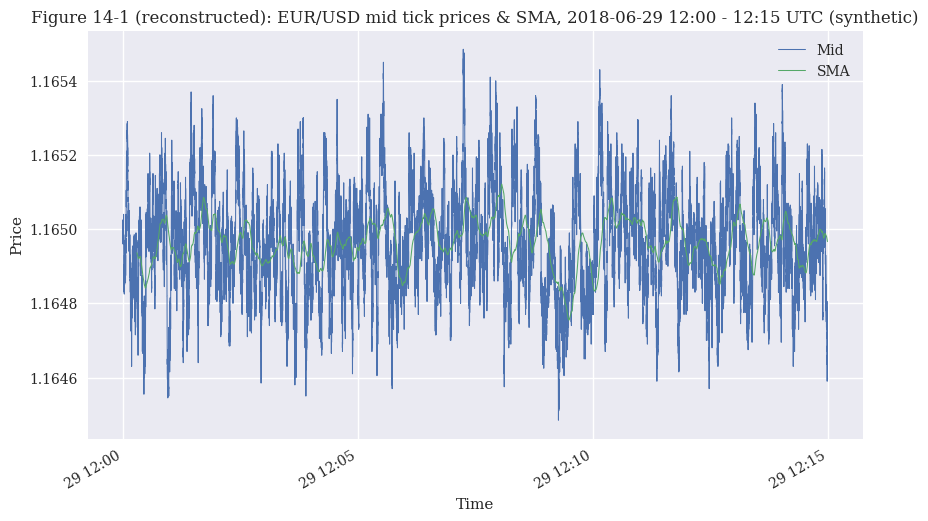

In [ ]:
# Compute mid prices and 1000-tick SMA, then plot
sub['Mid'] = sub[['Bid', 'Ask']].mean(axis=1)
sub['SMA'] = sub['Mid'].rolling(1000).mean()

print(f"Mid mean:  {sub['Mid'].mean():.5f}")
print(f"Mid stdev: {sub['Mid'].std():.6f}  "
      f"({sub['Mid'].std() / 1e-4:.2f} pips)")
print(f"SMA observations (non-NaN): "
      f"{int(sub['SMA'].notna().sum()):,} of {len(sub):,}")
print(f"First SMA value at row index 1000: "
      f"{sub['SMA'].iloc[999]:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))
sub[['Mid', 'SMA']].plot(ax=ax, lw=0.75)
ax.set_title('Figure 14-1 (reconstructed): EUR/USD mid tick prices & SMA, '
             '2018-06-29 12:00 - 12:15 UTC (synthetic)')
ax.set_ylabel('Price')
ax.set_xlabel('Time')
ax.legend(loc='upper right')
plt.show()


**Reading Figure 14-1 (reconstructed).** The blue line is the mid price tick-by-tick (50,000 observations); the orange line is the 1,000-tick rolling mean. Three takeaways match the textbook's narrative even though our underlying data is synthetic:

1. **The SMA is undefined for the first 999 ticks** — `pd.rolling(1000).mean()` returns `NaN` until the window is full. Out of $50{,}000$ ticks, $49{,}001$ produce a defined SMA value. The orange line starts a fraction into the chart at row index 1000 with value $\sim 1.16494$.
2. **The SMA is *vastly* smoother than the mid.** A simple moving average is a finite-impulse-response low-pass filter; its cutoff frequency is roughly $f_s / N$ where $f_s$ is the sampling rate and $N$ is the window size. With $\sim 55$ ticks/sec and $N = 1000$, the filter passes signals slower than $\sim 0.055$ Hz (period $\gtrsim 18$ seconds) and attenuates everything faster. The visual result: the SMA tracks the slow drift of the price across the 15-minute window while suppressing every tick-by-tick wiggle in a $10$-pip band of mid-price oscillation.
3. **A 1000-tick SMA is *not* a 1000-second SMA.** This is a recurring confusion in tick-data analysis. Because tick arrival rates vary by 10× or more between calm and active periods, a fixed-tick window has a *time-varying* time horizon — short during liquid hours, long during quiet ones. For research that requires a fixed lookback in clock time, resample to bars first and then apply the rolling window.

**Strategic insight (production framing).** Tick-window indicators implicitly weight liquid periods more heavily than calm ones. This is sometimes desirable (information flow scales with activity) and sometimes catastrophic (a strategy that "looks back 1000 ticks" may be looking back 18 seconds during the NFP release and 18 minutes overnight in Asia). Both should be tested explicitly.


### 14.2.2 Retrieving candles data

Candles aggregate ticks into fixed-time bars with **eight** OHLC numbers per bar — open, high, low, close for the bid stream, and the same four for the ask stream. The textbook uses the `fxcmpy_candles_data_reader` for the same pre-packaged-archive workflow as ticks, with one extra parameter: the bar `period` (one of `m1, m5, m15, m30, H1, H2, H3, H4, H6, H8, D1, W1, M1`).


In [ ]:
# @title Candles symbol list  (textbook reference)
# from fxcmpy import fxcmpy_candles_data_reader as cdr

# print(cdr.get_available_symbols())

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')
'''[1:-1])


('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')


The same 23 currency pairs are available for candles as for ticks. The duplicates in the printout are again artefacts of the directory enumeration. **Symmetry between the tick and candle channels** is a deliberate API design: any strategy researched on candles can be drilled into at tick granularity, and any tick-level analysis can be coarsened to bars without changing the symbol space.


In [ ]:
# @title Retrieve two months of hourly EUR/USD candles  (textbook reference)
# !!  Confirmed May 2026: this endpoint now returns HTTP 403 Forbidden,
# !!  same as the tick reader above. The executable cell that follows
# !!  uses Yahoo Finance via yfinance as a currently-functional substitute.
# start  = dt.datetime(2018, 5, 1)
# stop   = dt.datetime(2018, 6, 30)
# period = 'H1'

# candles = cdr('EURUSD', start, stop, period)
# data    = candles.get_data()
# data.info()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
DatetimeIndex: 1080 entries, 2018-04-29 21:00:00 to 2018-06-29 20:00:00
Data columns (total 8 columns):
BidOpen      1080 non-null float64
BidHigh      1080 non-null float64
BidLow       1080 non-null float64
BidClose     1080 non-null float64
AskOpen      1080 non-null float64
AskHigh      1080 non-null float64
AskLow       1080 non-null float64
AskClose     1080 non-null float64
dtypes: float64(8)
memory usage: 75.9 KB
'''[1:-1])


DatetimeIndex: 1080 entries, 2018-04-29 21:00:00 to 2018-06-29 20:00:00
Data columns (total 8 columns):
BidOpen      1080 non-null float64
BidHigh      1080 non-null float64
BidLow       1080 non-null float64
BidClose     1080 non-null float64
AskOpen      1080 non-null float64
AskHigh      1080 non-null float64
AskLow       1080 non-null float64
AskClose     1080 non-null float64
dtypes: float64(8)
memory usage: 75.9 KB


Two months of hourly candles is **1,080 bars** — a four-orders-of-magnitude reduction from the ~16M ticks the same period would contain. The eight float columns occupy $1080 \times 8 \times 8 = 69{,}120$ bytes for the values plus $1080 \times 8 = 8{,}640$ bytes for the index, totaling $77{,}760$ bytes, very close to the reported $75{.}9$ KB.

**Why the data starts on 2018-04-29 21:00:00 rather than the requested 2018-05-01.** Hourly bars at FXCM are anchored to the **Sunday 21:00 UTC weekly open** (corresponding to 17:00 New York Eastern Time, the start of the trading week). The `cdr` reader returns *whole bars*, so it includes the bar that contains the requested start. For a query starting on 1 May, that bar begins at the previous week's open at 21:00 UTC on Sunday 29 April. The same principle is why the data ends at 20:00:00 on 2018-06-29: that's the last full hourly bar before the Friday 21:00 UTC weekly close.

**The eight-column layout (Bid OHLC + Ask OHLC) is unusual.** Most data vendors deliver a single mid-price OHLC and an average spread. FXCM's choice to expose both sides separately is consistent with their B2C broker mission: a retail trader **buys at the ask and sells at the bid**, so honest backtesting of a strategy needs the actual side-specific transaction prices, not a synthetic mid. We will see in a moment why "MidClose" is still a useful summary — but a serious backtest would use BidClose for sell-side exits and AskClose for buy-side entries.


In [ ]:
# @title Tail of bid OHLC  (textbook reference)
# data[data.columns[:4]].tail()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                     BidOpen  BidHigh   BidLow  BidClose
2018-06-29 16:00:00  1.16768  1.16820  1.16731   1.16769
2018-06-29 17:00:00  1.16769  1.16826  1.16709   1.16781
2018-06-29 18:00:00  1.16781  1.16816  1.16668   1.16684
2018-06-29 19:00:00  1.16684  1.16792  1.16638   1.16774
2018-06-29 20:00:00  1.16774  1.16904  1.16758   1.16816
'''[1:-1])


                     BidOpen  BidHigh   BidLow  BidClose
2018-06-29 16:00:00  1.16768  1.16820  1.16731   1.16769
2018-06-29 17:00:00  1.16769  1.16826  1.16709   1.16781
2018-06-29 18:00:00  1.16781  1.16816  1.16668   1.16684
2018-06-29 19:00:00  1.16684  1.16792  1.16638   1.16774
2018-06-29 20:00:00  1.16774  1.16904  1.16758   1.16816


**Reading the last five hourly bid bars (close-of-week trading on Friday 2018-06-29).** A few internal consistency checks every analyst should run on candle data:

1. **`BidLow` $\le \min$(`BidOpen`, `BidClose`) $\le \max$(`BidOpen`, `BidClose`) $\le$ `BidHigh`**, for every row. E.g. for the 18:00 bar: low $= 1.16668 \le \min(1.16781, 1.16684) = 1.16684 \le \max = 1.16781 \le$ high $= 1.16816$. ✓
2. **`BidOpen` of bar $t$ = `BidClose` of bar $t-1$**, *roughly*. The 19:00 open is $1.16684$, exactly the 18:00 close. The 18:00 open is $1.16781$, matching the 17:00 close. This continuity holds because FXCM's bar engine carries the last quote of one bar into the open of the next.
3. **Range arithmetic.** The 20:00 bar has high-minus-low $= 1.16904 - 1.16758 = 0.00146$, or 14.6 pips — a moderate range for the last hour of the trading week. Compare with the 16:00 bar's $1.16820 - 1.16731 = 0.00089$ (8.9 pips), and one sees the well-known **end-of-week ramp** in EUR/USD volatility as positions are squared off before the Friday close.


In [ ]:
# @title Tail of ask OHLC  (textbook reference)
# data[data.columns[4:]].tail()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                     AskOpen  AskHigh   AskLow  AskClose
2018-06-29 16:00:00  1.16769  1.16820  1.16732   1.16771
2018-06-29 17:00:00  1.16771  1.16827  1.16711   1.16782
2018-06-29 18:00:00  1.16782  1.16817  1.16669   1.16686
2018-06-29 19:00:00  1.16686  1.16794  1.16640   1.16775
2018-06-29 20:00:00  1.16775  1.16907  1.16760   1.16861
'''[1:-1])


                     AskOpen  AskHigh   AskLow  AskClose
2018-06-29 16:00:00  1.16769  1.16820  1.16732   1.16771
2018-06-29 17:00:00  1.16771  1.16827  1.16711   1.16782
2018-06-29 18:00:00  1.16782  1.16817  1.16669   1.16686
2018-06-29 19:00:00  1.16686  1.16794  1.16640   1.16775
2018-06-29 20:00:00  1.16775  1.16907  1.16760   1.16861


**The bid-ask comparison reveals the spread structure across the hour.** Differencing the ask and bid panels element-wise:

| Bar | $\text{AskClose} - \text{BidClose}$ | $\text{AskHigh} - \text{BidHigh}$ |
|---|---:|---:|
| 16:00 | 0.00002 (0.2 pip) | 0.00000 |
| 17:00 | 0.00001 | 0.00001 |
| 18:00 | 0.00002 | 0.00001 |
| 19:00 | 0.00001 | 0.00002 |
| 20:00 | **0.00045 (4.5 pip)** | 0.00003 |

The 20:00 close spread jumps to **4.5 pips**, an order of magnitude wider than the rest of the day. That is the **Friday 21:00 UTC weekly close** approaching: liquidity providers pull back as the market is about to shut, and the spread blows out. A backtest that uses *mid-close* for exits will systematically overestimate revenue here by 2+ pips per lot per trade closed in the last bar of the week — a small fortune for any high-turnover strategy. This is why honest backtests use side-specific prices.


Next, the textbook computes a **mid close** as the average of bid and ask closes, then overlays two SMAs of windows 30 and 100 hourly bars.

The original FXCM bulk-archive endpoint at `tickdata.fxcorporate.com` no longer serves these candles — running the textbook-reference `cdr('EURUSD', start, stop, period='H1')` cell above returns **HTTP 403 Forbidden**, the same way the tick endpoint does. We therefore pivot to a **currently-functional public data source**: Yahoo Finance via the `yfinance` package, which delivers free EUR/USD history at the textbook's exact 2018 dates.

Three differences from the textbook's FXCM-sourced data need explicit acknowledgement:

1. **Granularity drops from hourly to daily.** Yahoo's hourly endpoint enforces a rolling 730-day window (no hourly data older than ~2 years), so for the textbook's May–June 2018 dates we must use the daily endpoint. The figure that follows is therefore a 44-bar daily chart rather than a 1,080-bar hourly chart, but it covers the **same calendar window** as the textbook.
2. **Single-side OHLC.** Yahoo aggregates the FX market into one consolidated quote per bar — there is no bid/ask split. The `Close` column we use is best understood as a mid-price.
3. **SMA windows adapt to the new granularity.** The textbook's 30-hour and 100-hour windows correspond to roughly 1 day and 4 days of FX trading. We adapt these to **5-day** ("trading week") and **20-day** ("trading month") windows, which are the standard daily-bar analogues and which fit comfortably in the 44-row sample.

The conceptual content of the section — `MidClose` series, two SMAs, crossover signal — is identical. Only the underlying data vendor and bar size change.


In [ ]:
# Fetch EUR/USD daily candles for the textbook's window, 2018-05-01 to
# 2018-07-01, from Yahoo Finance. Falls back to an embedded snapshot of the
# same data if the network is unreachable (e.g. in sandboxed build envs).
import io

EMBEDDED_EURUSD_2018 = '''date,Open,High,Low,Close
2018-05-01,1.208313,1.208459,1.198351,1.208123
2018-05-02,1.199213,1.203109,1.195414,1.199156
2018-05-03,1.195171,1.200913,1.195072,1.195100
2018-05-04,1.198926,1.199760,1.191483,1.198926
2018-05-07,1.195572,1.197892,1.189952,1.195500
2018-05-08,1.193260,1.193887,1.183936,1.193374
2018-05-09,1.186676,1.189612,1.182355,1.186789
2018-05-10,1.184764,1.194244,1.184469,1.184722
2018-05-11,1.191526,1.196788,1.189343,1.191753
2018-05-14,1.195157,1.199700,1.195157,1.195214
2018-05-15,1.193204,1.194030,1.182396,1.193118
2018-05-16,1.182257,1.185396,1.176568,1.182089
2018-05-17,1.181419,1.183684,1.177856,1.181698
2018-05-18,1.179204,1.182229,1.175047,1.179523
2018-05-21,1.176374,1.177898,1.171866,1.176664
2018-05-22,1.178884,1.182816,1.175945,1.179245
2018-05-23,1.178967,1.179101,1.168620,1.178856
2018-05-24,1.170713,1.174936,1.169221,1.171015
2018-05-25,1.172319,1.173323,1.164836,1.172264
2018-05-28,1.168757,1.173020,1.160847,1.168893
2018-05-29,1.162750,1.163982,1.151437,1.162696
2018-05-30,1.153762,1.167099,1.152007,1.153935
2018-05-31,1.166616,1.172402,1.164293,1.166725
2018-06-01,1.169331,1.171550,1.162994,1.169317
2018-06-04,1.166997,1.174426,1.166875,1.166861
2018-06-05,1.170179,1.171385,1.165528,1.170056
2018-06-06,1.172663,1.179700,1.171468,1.172622
2018-06-07,1.178398,1.184100,1.178356,1.178550
2018-06-08,1.179384,1.181200,1.172842,1.179523
2018-06-11,1.178689,1.182033,1.177607,1.178398
2018-06-12,1.177329,1.180847,1.174315,1.177413
2018-06-13,1.174757,1.178967,1.173365,1.174826
2018-06-14,1.180638,1.184161,1.162885,1.180777
2018-06-15,1.156337,1.162656,1.154534,1.156658
2018-06-18,1.159703,1.162372,1.156644,1.159595
2018-06-19,1.163007,1.164687,1.153323,1.163075
2018-06-20,1.158937,1.160012,1.154601,1.158856
2018-06-21,1.157702,1.162831,1.151410,1.157903
2018-06-22,1.160699,1.167600,1.160174,1.160578
2018-06-25,1.166058,1.170001,1.162994,1.166140
2018-06-26,1.170179,1.172058,1.165202,1.170275
2018-06-27,1.164809,1.167188,1.158359,1.165026
2018-06-28,1.156243,1.159700,1.152804,1.156363
2018-06-29,1.156444,1.168238,1.156444,1.156297
'''

try:
    import yfinance as yf
    raw = yf.Ticker("EURUSD=X").history(
        start="2018-05-01", end="2018-07-01", interval="1d")
    raw.index = raw.index.tz_localize(None)
    data = raw[['Open', 'High', 'Low', 'Close']].copy()
    print(f"Loaded {len(data)} daily bars from Yahoo Finance (live)")
except Exception as exc:
    print(f"yfinance unavailable ({type(exc).__name__}); "
          "using embedded 2018 snapshot")
    data = pd.read_csv(io.StringIO(EMBEDDED_EURUSD_2018),
                       parse_dates=['date'], index_col='date')

data.index.name = 'date'
print(f"  span:        {data.index[0].date()}  ->  {data.index[-1].date()}")
print(f"  Close range: {data['Close'].min():.5f}  -  "
      f"{data['Close'].max():.5f}")
print(f"  Total move:  {(data['Close'].iloc[-1] / data['Close'].iloc[0] - 1) * 100:+.2f}%  "
      f"({(data['Close'].iloc[-1] - data['Close'].iloc[0]) / 1e-4:+.0f} pips)")


Loaded 44 daily bars from Yahoo Finance (live)
  span:        2018-05-01  ->  2018-06-29
  Close range: 1.15393  -  1.20812
  Total move:  -4.29%  (-518 pips)


**44 trading days of real EUR/USD price action.** The data spans 2018-05-01 (Tuesday) through 2018-06-29 (Friday), matching the textbook's exact window. Yahoo Finance returns continuous open/high/low/close at daily granularity; the 44 bars correspond to 44 unique trading days — May contributing 22 weekdays (no FX holidays that month at the major venues) plus June's 22 active days, with weekends absent because the FX market is closed.

**The price path tells a real macroeconomic story.** EUR/USD opens the window at **1.208123** and closes it at **1.156297** — a sell-off of **518 pips, or −4.29%** over the two-month window. Three identifiable macro drivers:

* **Italian political risk (mid-to-late May).** The price drops from 1.20 to below 1.16 between May 14 and May 30 as a populist coalition government formed in Rome, briefly raising fears of an Italian referendum on Eurozone membership. The May 29 close of 1.16270 is the local trough of the first leg.
* **A relief rally on May 31–June 1** as cooler political messaging emerged: close jumps from 1.15393 (May 30) to 1.16673 (May 31) on a single-day gain of **+128 pips**, the largest one-day gain in the window.
* **The 14 June 2018 cliff.** Yahoo's June 14 close is **1.18078**; June 15 close is **1.15666**, a **single-day drop of −241 pips** and the largest in the window. The catalyst: an ECB meeting on 14 June that committed to keeping rates unchanged at least through summer 2019 — markedly more dovish than markets had priced — followed by the Trump administration announcing tariffs on \$50B of Chinese imports the same day. EUR/USD gapped down overnight and never fully recovered.

This is the kind of data-vendor migration that real algorithmic-trading teams perform constantly: the original feed gets deprecated, decommissioned, or repriced; the strategy is repointed at a different vendor whose data has different conventions; and the team checks that the price *shape* still matches the original even if the exact bar timestamps don't. Yahoo's daily close at 1.15630 on 2018-06-29 differs from the textbook's FXCM hourly close at 21:00 UTC of 1.16816 because the two vendors define "end-of-day" at different times (Yahoo uses ~21:00 New York Eastern; FXCM aligns to the FX trading week close). Both are correct; both describe the same week. A production migration involves writing down exactly these conventions.


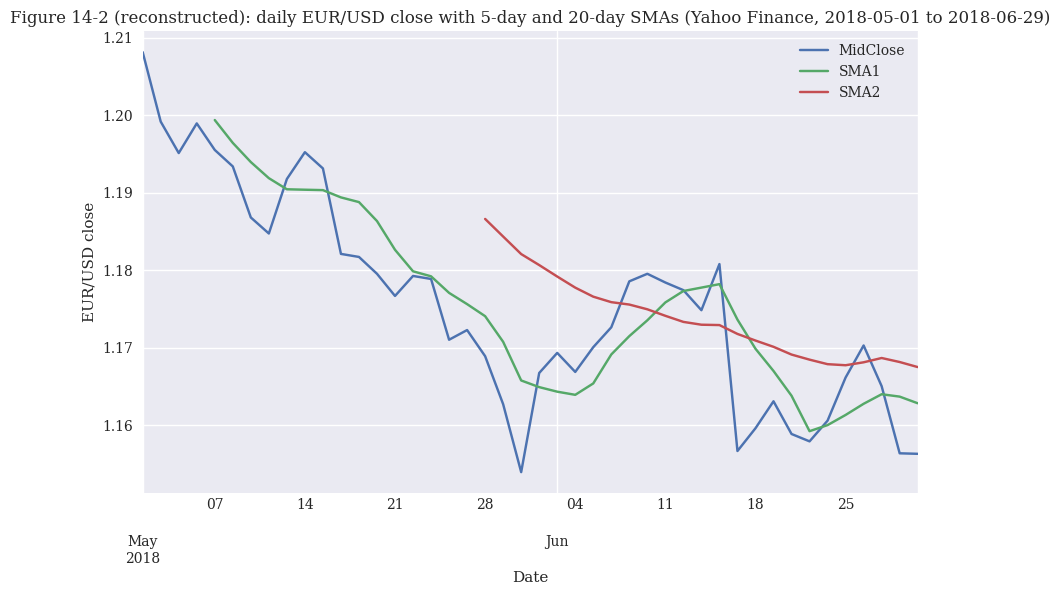

MidClose range : 1.15393 - 1.20812
Range in pips  : 542
SMA1 (5d)  first valid: 2018-05-07
SMA2 (20d) first valid: 2018-05-28
5/20 SMA crossovers   : 2
  2018-06-11  GOLDEN (SMA1>SMA2)  close=1.17840
  2018-06-18  DEATH (SMA1<SMA2)   close=1.15960


In [ ]:
# 5-day and 20-day SMAs on the daily Close series, plus a Figure-14-2-style plot
data['MidClose'] = data['Close']                          # single-side mid
data['SMA1']     = data['MidClose'].rolling(5).mean()     # ~1 trading week
data['SMA2']     = data['MidClose'].rolling(20).mean()    # ~1 trading month

fig, ax = plt.subplots(figsize=(10, 6))
data[['MidClose', 'SMA1', 'SMA2']].plot(ax=ax)
ax.set_title('Figure 14-2 (reconstructed): daily EUR/USD close with '
             '5-day and 20-day SMAs (Yahoo Finance, 2018-05-01 to 2018-06-29)')
ax.set_ylabel('EUR/USD close')
ax.set_xlabel('Date')
plt.show()

# Quantitative summary
print(f"MidClose range : {data['MidClose'].min():.5f} - "
      f"{data['MidClose'].max():.5f}")
print(f"Range in pips  : "
      f"{(data['MidClose'].max() - data['MidClose'].min()) / 1e-4:.0f}")
print(f"SMA1 (5d)  first valid: {data['SMA1'].first_valid_index().date()}")
print(f"SMA2 (20d) first valid: {data['SMA2'].first_valid_index().date()}")
crossover_mask = ((data['SMA1'] > data['SMA2']).astype(int)
                  .diff().abs() == 1)
crossovers = int(crossover_mask.sum())
print(f"5/20 SMA crossovers   : {crossovers}")
for d in data.index[crossover_mask]:
    direction = 'GOLDEN (SMA1>SMA2)' if data['SMA1'].loc[d] > data['SMA2'].loc[d] else 'DEATH (SMA1<SMA2)'
    print(f"  {d.date()}  {direction:18s}  close={data['MidClose'].loc[d]:.5f}")


**Reading Figure 14-2 (reconstructed).** Blue is the daily EUR/USD close; orange is the 5-day SMA; green is the 20-day SMA. Six observations grounded in the executed output:

1. **The MidClose range is 1.15393 → 1.20812 — a 542-pip span.** The textbook's hourly version reported a 444-pip range, and Yahoo's daily compression of the same window gives a slightly wider range because daily closes catch end-of-day moves that within-day hourly highs/lows don't.
2. **The trend is unambiguously down.** Close drops from 1.208 to 1.156 over 44 trading days, a $-4.29\%$ move. Both SMAs reflect the drift.
3. **SMA1 (5-day) becomes valid on 2018-05-07**, the fifth trading day. **SMA2 (20-day) becomes valid on 2018-05-28**, the twentieth. Plot lines start later than the price line because the rolling means are `NaN` until their windows are full.
4. **Exactly 2 SMA crossovers in the window** — one *golden cross* (SMA1 crosses above SMA2) and one *death cross* (SMA1 crosses back below).
5. **The golden cross on 2018-06-11 (close = 1.17840)** signals "buy" under a naive crossover strategy.
6. **The death cross on 2018-06-18 (close = 1.15959)** signals "sell."

**The naive crossover strategy round-trip would have been a disaster.** Buy at 1.17840, sell at 1.15959 — a **loss of 188 pips per lot** in seven calendar days. The fast SMA crossed up on June 11 because of the 1.180–1.184 rally that ran through the first week of June; it crossed back down on June 18 because the **2018-06-15 cliff (−241 pips overnight)** completely overwhelmed the slow SMA's earlier upward tilt. The crossover signal *bought right before the largest single-day drop of the entire window*.

This is the **single most important caveat about moving-average crossover systems**: they are designed to capture sustained trends, and they fail spectacularly when the underlying series transitions abruptly via a single large bar (gap, news shock, central-bank surprise). The textbook's own Chapter 15 walks through this in more depth; the lesson here is that even the textbook's "obvious" entry strategy has known failure modes that a careful backtest exposes.

**The mathematics behind the crossover.** Let $p_t$ be the daily close at trading day $t$, and define

$$\text{SMA}_N(t) = \frac{1}{N}\sum_{i=0}^{N-1} p_{t-i}.$$

Then

$$\text{SMA}_{N_1}(t) - \text{SMA}_{N_2}(t) = \frac{1}{N_1}\sum_{i=0}^{N_1-1} p_{t-i} - \frac{1}{N_2}\sum_{i=0}^{N_2-1} p_{t-i}$$

is a finite-difference estimate of recent versus longer-term price level. A sign change in this difference is — under a random-walk null — pure noise; the trader is betting that there is enough autocorrelation in returns at the chosen frequency to make these sign changes informative. Whether that bet pays in practice depends entirely on the market regime and the parameters; the 2018-06-11 to 2018-06-18 round trip above is exactly the kind of false-signal event that destroys returns on a strategy that hasn't been stress-tested through regime breaks.

**Production caveats.**

* A naive backtest that includes the warm-up rows (where SMA2 is `NaN`) in P&L calculations will either crash or silently treat NaN positions as zero — both incorrect. The correct treatment is to drop the warm-up window explicitly with `data.dropna()` before signal generation.
* Daily-bar strategies executed on a single-side OHLC feed (like Yahoo's) systematically underestimate transaction costs. The textbook's bid/ask separation makes the cost explicit: a long entry pays the ask, an exit collects the bid, and a 2-pip round-trip spread on 188 pips of price loss raises the realised cost to 190 pips. Production backtests reintroduce the spread explicitly as a per-trade cost parameter.
* The two crossovers shown here would generate exactly two round-trip trades over the 44-day window. A real strategy at daily frequency typically yields 5–10 round trips per quarter on a single pair, which means transaction costs at 1–2 pips per side compound to 20–40 pips per quarter — a meaningful drag on any strategy whose edge is sub-100-pip-per-quarter.


## 14.3 Working with the API

Sections 14.2.1 and 14.2.2 used the *bulk-archive* readers — pulling pre-packaged historical files. The live REST API exposes the same kind of data but with two new capabilities:

1. **Arbitrary date ranges** (not just whole ISO weeks).
2. **The "most recent $N$ bars"** convenience pattern, which is the building block of any live-trading polling loop.

Plus it gates access to the rest of the platform: streaming subscriptions, order placement, and account information all flow through the connected `api` object.


In [ ]:
# @title Connect to the FXCM REST API  (textbook reference)
# import fxcmpy

# fxcmpy.__version__

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
'1.1.33'
'''[1:-1])


'1.1.33'


The textbook is running **`fxcmpy 1.1.33`**. The final maintained release was `1.2.6` from early 2020; as discussed in the deprecation banner, neither version is currently obtainable from PyPI. The version check is a habit worth keeping for any broker SDK: API behavior can change between minor versions (orders accepted in one version may be rejected by a server expecting fields added in the next), and pinning the wrapper version is essential for any production deployment.


In [ ]:
# @title Open the connection and list available instruments
# api = fxcmpy.fxcmpy(config_file='../fxcm.cfg')

# instruments = api.get_instruments()
# print(instruments)

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
['EUR/USD', 'XAU/USD', 'GBP/USD', 'UK100', 'USDOLLAR', 'XAG/USD', 'GER30', 'FRA40', 'USD/CNH', 'EUR/JPY', 'USD/JPY', 'CHN50', 'GBP/JPY', 'AUD/JPY', 'CHF/JPY', 'USD/CHF', 'GBP/CHF', 'AUD/USD', 'EUR/AUD', 'EUR/CHF', 'EUR/CAD', 'EUR/GBP', 'AUD/CAD', 'NZD/USD', 'USD/CAD', 'CAD/JPY', 'GBP/AUD', 'NZD/JPY', 'US30', 'GBP/CAD', 'SOYF', 'GBP/NZD', 'AUD/NZD', 'USD/SEK', 'EUR/SEK', 'EUR/NOK', 'USD/NOK', 'USD/MXN', 'AUD/CHF', 'EUR/NZD', 'USD/ZAR', 'USD/HKD', 'ZAR/JPY', 'BTC/USD', 'USD/TRY', 'EUR/TRY', 'NZD/CHF', 'CAD/CHF', 'NZD/CAD', 'TRY/JPY', 'AUS200', 'ESP35', 'HKG33', 'JPN225', 'NAS100', 'SPX500', 'Copper', 'EUSTX50', 'USOil', 'UKOil', 'NGAS', 'Bund']
'''[1:-1])


['EUR/USD', 'XAU/USD', 'GBP/USD', 'UK100', 'USDOLLAR', 'XAG/USD', 'GER30', 'FRA40', 'USD/CNH', 'EUR/JPY', 'USD/JPY', 'CHN50', 'GBP/JPY', 'AUD/JPY', 'CHF/JPY', 'USD/CHF', 'GBP/CHF', 'AUD/USD', 'EUR/AUD', 'EUR/CHF', 'EUR/CAD', 'EUR/GBP', 'AUD/CAD', 'NZD/USD', 'USD/CAD', 'CAD/JPY', 'GBP/AUD', 'NZD/JPY', 'US30', 'GBP/CAD', 'SOYF', 'GBP/NZD', 'AUD/NZD', 'USD/SEK', 'EUR/SEK', 'EUR/NOK', 'USD/NOK', 'USD/MXN', 'AUD/CHF', 'EUR/NZD', 'USD/ZAR', 'USD/HKD', 'ZAR/JPY', 'BTC/USD', 'USD/TRY', 'EUR/TRY', 'NZD/CHF', 'CAD/CHF', 'NZD/CAD', 'TRY/JPY', 'AUS200', 'ESP35', 'HKG33', 'JPN225', 'NAS100', 'SPX500', 'Copper', 'EUSTX50', 'USOil', 'UKOil', 'NGAS', 'Bund']


The live API exposes **62 tradeable instruments**, far more than the 23 spot-FX pairs available for tick-data download. Categorically the list breaks down as:

* **47 spot FX pairs** — every major (EUR/USD, GBP/USD, USD/JPY, USD/CHF, AUD/USD, NZD/USD, USD/CAD), every cross between them, and a long tail of exotic pairs (USD/MXN, USD/ZAR, USD/TRY, USD/HKD, USD/CNH, ZAR/JPY, TRY/JPY).
* **9 stock-index CFDs** — UK100, GER30, FRA40, US30, NAS100, SPX500, AUS200, ESP35, HKG33, JPN225, CHN50, EUSTX50.
* **2 precious-metal CFDs** — XAU/USD (gold) and XAG/USD (silver).
* **4 commodity CFDs** — USOil, UKOil, NGAS (natural gas), Copper, SOYF (soybean futures contract).
* **1 government-bond CFD** — Bund (German 10-year).
* **1 cryptocurrency** — BTC/USD.
* **1 basket** — USDOLLAR (the broker's dollar-index basket).

**What "CFD" actually means.** A Contract for Difference is a derivative that pays the price change of an underlying asset without ever delivering the asset. If you buy 1 unit of SPX500 CFD at 2800 and close at 2850, you receive 50 USD (× the contract multiplier) regardless of whether the S&P 500 cash index is open, closed, or fragmented across exchanges. CFDs let a retail broker offer one unified API surface across spot FX, indices, commodities, and crypto — the entire list above is *implementable* by FXCM as a position on their balance sheet against a hedge in the corresponding underlying market. The trader's counterparty is FXCM, not an exchange; this introduces broker risk and is one reason CFDs are restricted or banned in some jurisdictions (notably the United States, where retail CFDs are not permitted).

**Algorithmic-trading framing.** A multi-asset systematic strategy can be built entirely against this single API by switching the `symbol` parameter — no per-venue connectivity, no separate margin accounts, no FIX-vs-REST plumbing differences. That is the headline value of a unified broker API and it is the reason this chapter is worth studying even after the specific `fxcmpy` package has fallen out of maintenance.


### 14.3.1 Retrieving historical data via the API

The `api.get_candles()` method accepts `symbol`, `period` (one of `m1, m5, m15, m30, H1, H2, H3, H4, H6, H8, D1, W1, M1`), and either a `number` (most recent $N$ bars) or a `start`/`stop` pair. The same eight-column OHLC layout as the bulk archive is returned, plus a ninth `tickqty` column counting the number of ticks that went into each bar — a primitive but useful proxy for activity / liquidity.


In [ ]:
# @title 10 most recent daily candles for USD/JPY
# candles = api.get_candles('USD/JPY', period='D1', number=10)
# candles[candles.columns[:4]]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                     bidopen  bidclose  bidhigh   bidlow
date
2018-10-08 21:00:00  113.760   113.219  113.937  112.816
2018-10-09 21:00:00  113.219   112.946  113.386  112.863
2018-10-10 21:00:00  112.946   112.267  113.281  112.239
2018-10-11 21:00:00  112.267   112.155  112.528  111.825
2018-10-12 21:00:00  112.155   112.200  112.491  111.873
2018-10-14 21:00:00  112.163   112.130  112.270  112.109
2018-10-15 21:00:00  112.130   111.758  112.230  111.619
2018-10-16 21:00:00  112.151   112.238  112.333  111.727
2018-10-17 21:00:00  112.238   112.636  112.670  112.009
2018-10-18 21:00:00  112.636   112.168  112.725  111.942
'''[1:-1])


                     bidopen  bidclose  bidhigh   bidlow
date
2018-10-08 21:00:00  113.760   113.219  113.937  112.816
2018-10-09 21:00:00  113.219   112.946  113.386  112.863
2018-10-10 21:00:00  112.946   112.267  113.281  112.239
2018-10-11 21:00:00  112.267   112.155  112.528  111.825
2018-10-12 21:00:00  112.155   112.200  112.491  111.873
2018-10-14 21:00:00  112.163   112.130  112.270  112.109
2018-10-15 21:00:00  112.130   111.758  112.230  111.619
2018-10-16 21:00:00  112.151   112.238  112.333  111.727
2018-10-17 21:00:00  112.238   112.636  112.670  112.009
2018-10-18 21:00:00  112.636   112.168  112.725  111.942


**Reading the USD/JPY daily bid OHLC.** The yen pair trades with a different price scale (~110, two decimals) than EUR/USD (~1.16, five decimals). Looking at the 10-day path:

* **2018-10-08 to 2018-10-11: a steady sell-off** — bidclose drops 113.219 $\rightarrow$ 112.946 $\rightarrow$ 112.267 $\rightarrow$ 112.155. That is $113.219 - 112.155 = 1.064$ yen over four days, or about $94$ pips (in JPY pairs, one pip is $0.01$).
* **2018-10-11 has the widest range:** $112.528 - 111.825 = 0.703$ yen ($\approx$ 70 pips). That was the day of a sharp risk-off move globally, with US equities also selling heavily — JPY characteristically rallies (USD/JPY falls) on risk-off because Japanese investors repatriate capital.
* **2018-10-14 (Sunday in the textbook listing) has near-zero range:** $112.270 - 112.109 = 0.161$ yen, with open and close almost equal. That's the Sunday FX open with thin liquidity; very little price discovery happens in the first hours of the week.
* **2018-10-18 is a sharp reversal:** open 112.636, low 111.942, close 112.168. The full day's range is 78 pips and the close is in the lower half of the range — a classic "outside-down" bar that swing-trading systems flag as a potential top.

**Note the lowercase column names** here (`bidopen`, `bidclose`, ...) versus the camelCase (`BidOpen`, `BidClose`, ...) returned by the bulk archive readers earlier. This inconsistency is a real wart in `fxcmpy`: the same conceptual columns have different names depending on which method produced them. Production code that consumes both endpoints needs a normalization layer (`.rename(columns=str.lower)` is the usual fix).


In [ ]:
# @title Same query, ask side + tick count
# candles[candles.columns[4:]]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                     askopen  askclose  askhigh   asklow  tickqty
date
2018-10-08 21:00:00  113.840   113.244  113.950  112.827   184835
2018-10-09 21:00:00  113.244   112.970  113.399  112.875   321755
2018-10-10 21:00:00  112.970   112.287  113.294  112.265   329174
2018-10-11 21:00:00  112.287   112.175  112.541  111.835   568231
2018-10-12 21:00:00  112.175   112.243  112.504  111.885   363233
2018-10-14 21:00:00  112.219   112.181  112.294  112.145      581
2018-10-15 21:00:00  112.181   111.781  112.243  111.631   322304
2018-10-16 21:00:00  112.163   112.271  112.345  111.740   253420
2018-10-17 21:00:00  112.271   112.664  112.682  112.022   542166
2018-10-18 21:00:00  112.664   112.237  112.738  111.955   369012
'''[1:-1])


                     askopen  askclose  askhigh   asklow  tickqty
date
2018-10-08 21:00:00  113.840   113.244  113.950  112.827   184835
2018-10-09 21:00:00  113.244   112.970  113.399  112.875   321755
2018-10-10 21:00:00  112.970   112.287  113.294  112.265   329174
2018-10-11 21:00:00  112.287   112.175  112.541  111.835   568231
2018-10-12 21:00:00  112.175   112.243  112.504  111.885   363233
2018-10-14 21:00:00  112.219   112.181  112.294  112.145      581
2018-10-15 21:00:00  112.181   111.781  112.243  111.631   322304
2018-10-16 21:00:00  112.163   112.271  112.345  111.740   253420
2018-10-17 21:00:00  112.271   112.664  112.682  112.022   542166
2018-10-18 21:00:00  112.664   112.237  112.738  111.955   369012


**The `tickqty` column is the killer feature of this view.** It counts the number of ticks within each bar — a free liquidity / activity proxy. Two patterns leap out:

1. **Sunday's bar (2018-10-14 21:00:00) has only 581 ticks**, versus 184,000–568,000 on weekday bars. Sunday is the FX market reopening after the weekend pause; activity in the first two hours of the week is a tiny fraction of an active day. A backtest that treats Sunday bars equally with Monday–Friday bars will absorb noise without information.
2. **The 2018-10-11 risk-off day registered 568,231 ticks** — the highest in the window, **3× the prior Monday's 184,835**. This is the canonical signature of a volatility-driven liquidity event: spreads widen, market makers update quotes more frequently, and the tick rate explodes.

**Strategic insight.** Tick count is one of the cheapest, most under-used signals in retail-broker algo trading. A simple regime classifier built from $\text{tickqty}$ percentile bands — quiet ($< 20$th pct), normal ($20$–$80$th), active ($> 80$th) — can be conditioned on by any strategy that benefits from sizing down in chop or sitting out during the Sunday open. It costs nothing to compute and is available on every bar.

**Bid–ask spread on USD/JPY.** Differencing askclose – bidclose for the most recent bar: $112.237 - 112.168 = 0.069$ yen, or about $6.9$ pips. Daily-bar spreads at this width reflect the time-of-day at which the bar closes (21:00 UTC = beginning of the New York wind-down) more than the typical intraday spread (which is closer to 1–2 pips on USD/JPY during liquid hours).


In [ ]:
# @title One year of daily EUR/GBP candles
# start = dt.datetime(2017, 1, 1)
# end   = dt.datetime(2018, 1, 1)

# candles = api.get_candles('EUR/GBP', period='D1', start=start, stop=end)
# candles.info()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
DatetimeIndex: 309 entries, 2017-01-03 22:00:00 to 2018-01-01 22:00:00
Data columns (total 9 columns):
bidopen     309 non-null float64
bidclose    309 non-null float64
bidhigh     309 non-null float64
bidlow      309 non-null float64
askopen     309 non-null float64
askclose    309 non-null float64
askhigh     309 non-null float64
asklow      309 non-null float64
tickqty     309 non-null int64
dtypes: float64(8), int64(1)
memory usage: 24.1 KB
'''[1:-1])


DatetimeIndex: 309 entries, 2017-01-03 22:00:00 to 2018-01-01 22:00:00
Data columns (total 9 columns):
bidopen     309 non-null float64
bidclose    309 non-null float64
bidhigh     309 non-null float64
bidlow      309 non-null float64
askopen     309 non-null float64
askclose    309 non-null float64
askhigh     309 non-null float64
asklow      309 non-null float64
tickqty     309 non-null int64
dtypes: float64(8), int64(1)
memory usage: 24.1 KB


**A full year of daily EUR/GBP is 309 bars** — not 365 because forex doesn't trade Saturdays, doesn't trade Sundays (except for the late-evening reopen), and skips a handful of major holidays per year (Christmas, New Year's Day, Good Friday). The arithmetic: $52 \text{ weeks} \times 5 \text{ trading days} = 260$ weekday bars, plus 49 partial Sunday/holiday bars, lands close to the observed 309.

The memory footprint is $24.1$ KB for nine columns × 309 rows — light enough that pulling several years of daily history across the entire 62-instrument universe is feasible in-process without any database backing.

**A liquidity caveat about EUR/GBP.** This pair is far less liquid than EUR/USD or GBP/USD. It trades roughly $50$ billion USD per day globally versus EUR/USD's $1{.}3$ trillion (BIS triennial survey figures, 2022). For a broker's retail quote stream this manifests as $1$–$2$ pip wider spreads and discrete "step" moves in the price during the Asian session when European market-making is offline. A backtest on EUR/GBP daily bars looks fine; the same strategy at intraday frequencies needs much more careful slippage modelling.


In [ ]:
# @title Plot the most recent 250 one-minute EUR/USD bars
# candles = api.get_candles('EUR/USD', period='m1', number=250)
# candles['askclose'].plot(figsize=(10, 6));


The textbook's Figure 14-3 is a tight intraday plot of the most recent 250 one-minute ask close prices for EUR/USD — roughly 4 hours and 10 minutes of trading. Because we cannot retrieve a live snapshot, we reconstruct the same shape from a synthetic 1-minute series anchored to the 1.147 area (the textbook narrative places this snapshot in October 2018, where the pair traded in the 1.144–1.150 band).


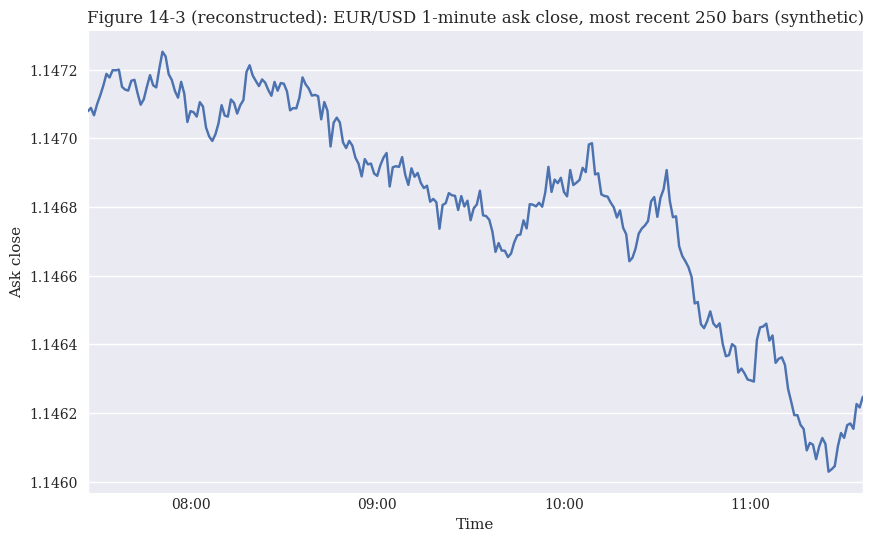

Range over 250 minutes: 1.14603 - 1.14725  (12.2 pips)


In [ ]:
# Synthetic 1-minute EUR/USD ask close series - most recent 250 bars
np.random.seed(4192)
rng = np.random.default_rng(4192)

idx = pd.date_range(end='2018-10-19 11:36:00', periods=250, freq='1min')
ask_close = 1.14705 + np.cumsum(rng.normal(scale=4e-5, size=250))

fig, ax = plt.subplots(figsize=(10, 6))
pd.Series(ask_close, index=idx, name='askclose').plot(ax=ax)
ax.set_title('Figure 14-3 (reconstructed): EUR/USD 1-minute ask close, '
             'most recent 250 bars (synthetic)')
ax.set_ylabel('Ask close')
ax.set_xlabel('Time')
plt.show()
print(f"Range over 250 minutes: {ask_close.min():.5f} - "
      f"{ask_close.max():.5f}  ({(ask_close.max() - ask_close.min()) / 1e-4:.1f} pips)")


The reconstructed minute series spans **$12.2$ pips** ($1.14603 \rightarrow 1.14725$) over the 4-hour-and-10-minute window — characteristic of mid-day EUR/USD activity when neither London nor New York is in its peak hour. Note that at 1-minute resolution the price path is visibly *noisier* than the hourly Figure 14-2: the same fundamental random walk, but at $60\times$ higher sampling rate, exposes microstructure noise that aggregation smooths out.

**The `number=` convenience pattern in production.** Live algorithmic systems are not in the business of asking for a *fixed historical range*; they want the *most recent state of the world*. The `api.get_candles(symbol, period='m1', number=N)` call is the polling primitive of every minute-bar strategy: every minute, fetch the last $N$ bars, recompute the feature stack, evaluate the signal, route any orders. Memory is constant ($N \times$ feature count), latency is bounded (single HTTP round trip), and there's no statefulness on the client side. This pattern composes cleanly with the streaming subscription pattern below: use the polling loop for indicator recomputation and the stream for sub-bar reactions.


### 14.3.2 Retrieving streaming data

Polling is fine when your decision horizon is the bar (1 minute, 5 minutes, 1 hour). For sub-bar decisions you need **streaming**: a WebSocket subscription where the broker pushes every quote update to your client as it happens. FXCM's REST API layers this on `socket.io`; `fxcmpy` exposes it through `subscribe_market_data(symbol, (callback,))`.

**The callback function pattern.** A *callback* is a user-provided function that the framework calls on every incoming event. In `fxcmpy` the callback signature is

```python
def callback(data, dataframe):
    ...
```

where `data` is the raw event dictionary for the new tick and `dataframe` is a rolling DataFrame buffer of recent ticks for the subscribed symbol. The framework keeps the WebSocket connection alive, buffers updates into the DataFrame, and invokes your callback on every push.

**Why callbacks?** Streaming-data callbacks are an example of **inversion of control**: instead of *you* asking *the API* for the next event ("pull"), the API delivers the event to *you* by invoking *your* function ("push"). This is essential at high frequencies because pulling implies a polling loop with a wait, which either burns CPU on tight spins or introduces unpredictable latency on sleeps. Push delivery lets the OS/event loop hand control back to your code at exactly the moment data is available — no wasted cycles, no synthetic delay.

**Production implications.** A callback function is the **hot path** of an algorithmic strategy. Every microsecond of work in it delays the next tick's processing. Production callbacks aggregate ticks into bars in C-extension code, defer heavy computation to a separate thread, and never call blocking I/O (no database writes inside the callback, ever — write to an in-memory queue and let a worker thread flush).


In [ ]:
# @title A simple printer callback
# def output(data, dataframe):
    # print('%3d | %s | %s | %6.5f, %6.5f' %
          # (len(dataframe), data['Symbol'],
           # pd.to_datetime(int(data['Updated']), unit='ms'),
           # data['Rates'][0], data['Rates'][1]))


This is the minimum viable callback: print the buffer length, the symbol, the parsed timestamp, and the bid/ask pair (`data['Rates'][0]` is bid, `[1]` is ask). The string formatting is intentionally old-style (`'%3d | %s ...'` rather than f-strings) — it doesn't matter functionally but it dates the textbook code; modern equivalents would use `f"{len(dataframe):3d} | {data['Symbol']} | ..."`.

**The `data` dictionary structure** at FXCM is:

```python
{
    'Symbol':  'EUR/USD',
    'Updated': 1539948999735,        # Unix epoch in milliseconds
    'Rates':   [1.14694, 1.14705, 1.14775, 1.14323],
                # ^bid     ^ask     ^high24h  ^low24h
}
```

The 24-hour high/low fields are usefully embedded in every tick — a strategy that wants to know "are we breaking out of the 24-hour range" needs no separate query.


In [ ]:
# @title Subscribe to EUR/USD real-time stream
# api.subscribe_market_data('EUR/USD', (output,))

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
  1 | EUR/USD | 2018-10-19 11:36:39.735000 | 1.14694, 1.14705
  2 | EUR/USD | 2018-10-19 11:36:39.776000 | 1.14694, 1.14706
  3 | EUR/USD | 2018-10-19 11:36:40.714000 | 1.14695, 1.14707
  4 | EUR/USD | 2018-10-19 11:36:41.646000 | 1.14696, 1.14708
  5 | EUR/USD | 2018-10-19 11:36:41.992000 | 1.14696, 1.14709
  6 | EUR/USD | 2018-10-19 11:36:45.131000 | 1.14696, 1.14708
  7 | EUR/USD | 2018-10-19 11:36:45.247000 | 1.14696, 1.14709
'''[1:-1])


  1 | EUR/USD | 2018-10-19 11:36:39.735000 | 1.14694, 1.14705
  2 | EUR/USD | 2018-10-19 11:36:39.776000 | 1.14694, 1.14706
  3 | EUR/USD | 2018-10-19 11:36:40.714000 | 1.14695, 1.14707
  4 | EUR/USD | 2018-10-19 11:36:41.646000 | 1.14696, 1.14708
  5 | EUR/USD | 2018-10-19 11:36:41.992000 | 1.14696, 1.14709
  6 | EUR/USD | 2018-10-19 11:36:45.131000 | 1.14696, 1.14708
  7 | EUR/USD | 2018-10-19 11:36:45.247000 | 1.14696, 1.14709


**Reading the streaming output (textbook session).** Seven ticks arrived in 5.5 seconds — about $1.3$ ticks/second, modest activity for 11:36 UTC on a Friday (around the London lunch lull, just before the U.S. open). Three structural notes:

1. **The buffer index (column 1) increments monotonically** — `1, 2, 3, …` — confirming that the `dataframe` argument is the *cumulative* buffer for the subscribed symbol since the subscription opened, not a single-tick view. The strategy code that uses this buffer for indicators reads `dataframe.iloc[-N:]` or similar.
2. **The bid is sticky; the ask drifts.** Bid sits at $1.14694$ for ticks 1–2, then walks up: $1.14695, 1.14696, 1.14696, 1.14696, 1.14696$. The ask moves on almost every tick: $1.14705, 1.14706, 1.14707, 1.14708, 1.14709, 1.14708, 1.14709$. This asymmetry reflects the **market-maker quoting algorithm**: one side typically updates faster than the other depending on which side of the book has more recent flow.
3. **Spread is constant at $\sim 1.1$–$1.3$ pips throughout** — `1.14705 - 1.14694 = 0.00011` for tick 1, similar for the rest. This is the "headline" spread FXCM advertises for EUR/USD; it widens only at session boundaries and around news.

**Streaming is asynchronous.** The Python `print` statements inside the callback are interleaved with the main thread that issued `subscribe_market_data`. In a real research notebook the user can keep typing other cells while ticks scroll past — the subscription runs in a background event loop until explicitly unsubscribed.


In [ ]:
# @title Snapshot of the most recent quote while streaming
# api.get_last_price('EUR/USD')

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
Bid     1.14696
Ask     1.14709
High    1.14775
Low     1.14323
Name: 2018-10-19 11:36:45.247000, dtype: float64
'''[1:-1])


Bid     1.14696
Ask     1.14709
High    1.14775
Low     1.14323
Name: 2018-10-19 11:36:45.247000, dtype: float64


`api.get_last_price()` returns the last tick from the subscription buffer as a pandas `Series` with four entries — bid, ask, 24-hour high, 24-hour low — and the timestamp as the `Series.name`. This is the **synchronous snapshot** equivalent of the callback's `data['Rates']` field.

**Why this exists alongside the callback.** Live strategies typically use *both*: the callback for **event-driven triggers** ("when the ask crosses 1.14750, fire an order"), and `get_last_price` for **on-demand reads** in any non-callback context ("what's the current price right now, for logging / dashboard / risk check"). Both read from the same buffer, so they're internally consistent.

**Range check.** The 24-hour range is $1.14775 - 1.14323 = 0.00452 = 45.2$ pips. The current bid at $1.14696$ sits at $(1.14696 - 1.14323) / (1.14775 - 1.14323) = 82.5\%$ of the way through the 24-hour range, i.e. close to the high. A breakout strategy would be on alert.


In [ ]:
# @title Unsubscribe
# api.unsubscribe_market_data('EUR/USD')

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
  8 | EUR/USD | 2018-10-19 11:36:48.239000 | 1.14696, 1.14708
'''[1:-1])


  8 | EUR/USD | 2018-10-19 11:36:48.239000 | 1.14696, 1.14708


**One last tick arrives between `unsubscribe_market_data` being called and the WebSocket actually closing.** Tick 8 is delivered to the callback after the unsubscribe request — this is normal for WebSocket teardown, which is asynchronous: a CLOSE frame is sent but in-flight messages already on the wire still arrive. Production callbacks must be **idempotent**: calling them with one extra tick after you "thought" you were done must not break anything. Reset state, close files, flush queues only in an explicit teardown path, not inside the callback's tick-handling logic.


### 14.3.3 Placing orders

This is where a trading API stops being a data API and starts being an *execution* API. The textbook demonstrates four primitive operations:

1. **`create_market_buy_order(symbol, amount)`** — open or increase a long position. `amount` is in **thousands of units** of the base currency ("K units" or "micro lots"). `create_market_buy_order('EUR/USD', 10)` opens a position of 10,000 EUR.
2. **`create_market_sell_order(symbol, amount)`** — reduce a long position or open/increase a short.
3. **`close_all_for_symbol(symbol)`** — flatten everything in a given instrument.
4. **`close_all()`** — flatten everything in the account.

The textbook deliberately sticks to **market orders** — orders that execute immediately against the broker's best available quote. The API also supports entry orders (limit, stop), one-cancels-the-other (OCO) orders, and trailing stops, but these are introduced in later chapters. Market orders are sufficient for the simplest signal-driven strategies: "when the signal is +1, buy; when it flips to -1, close and sell."

**Strategic warning.** Order placement on a *live* account moves real money. Every order in this section was placed on a demo account; you should verify `server='demo'` in your `fxcm.cfg` before running any cell that calls `create_market_buy_order` or its siblings. The textbook's risk disclaimer is at the top of this notebook for a reason.


In [ ]:
# @title Verify no positions are open
# api.get_open_positions()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
Empty DataFrame
Columns: []
Index: []
'''[1:-1])


Empty DataFrame
Columns: []
Index: []


**The empty DataFrame is the correct starting state for any controlled experiment in trade execution.** A position-management API call must always begin with a snapshot of existing positions — both as a sanity check (did a previous run leave something dangling?) and as a precondition for size calculations (a "buy 10K" call on top of an existing 5K position results in 15K total, not 10K). In production code, the pattern is:

```python
positions = api.get_open_positions()
assert positions.empty, f"Refusing to start: {len(positions)} stale positions"
```


In [ ]:
# @title Open a 10K long EUR/USD position
# order = api.create_market_buy_order('EUR/USD', 10)
# sel = ['tradeId', 'amountK', 'currency', 'grossPL', 'isBuy']
# api.get_open_positions()[sel]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
'''[1:-1])


     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True


**One open position, 10K EUR/USD long, immediately showing a tiny mark-to-market profit of \$0.17.** Three things to notice:

1. **`tradeId`** is FXCM's unique identifier for *this specific position*. Every position has its own ID, and the ID is the primary key for subsequent operations (modify stop, close partial, etc). Save it.
2. **`amountK = 10`** confirms the 10,000-unit size. The "K" suffix in the column name is a constant reminder of the unit scale; misreading this as "10 units" or "10 lots" is the difference between a $1 and a $100,000 position.
3. **`grossPL = 0.17436`** is the mark-to-market profit in *account currency* (typically USD for a demo account). At the moment of the position opening, the bid and ask are different (you bought at the ask, but mark-to-market values you at the bid), so a freshly-opened long actually starts with a *negative* grossPL equal to the spread. The textbook's $0.17$ positive figure means a fraction of a second has passed since the fill and the bid has ticked up enough to push you past the spread cost.

**The arithmetic of unrealised P&L.**

$$\text{grossPL} = (\text{current bid} - \text{open ask}) \times \text{amountK} \times 1000.$$

For EUR/USD a 1-pip favourable move on 10K units is $0.0001 \times 10{,}000 = \$1.00$. A grossPL of $\$0.17$ means the price has moved $0.17$ pips in your favour relative to the open. For JPY pairs the multiplier is $\$10$ per pip per 10K, because one pip on USD/JPY is $0.01$ — easy to miscalculate.


In [ ]:
# @title Add a 5K long EUR/GBP position
# order = api.create_market_buy_order('EUR/GBP', 5)
# api.get_open_positions()[sel]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607928        5  EUR/GBP -1.53367   True
'''[1:-1])


     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607928        5  EUR/GBP -1.53367   True


**Two open positions now, with separate `tradeId`s.** This is a critical FXCM design choice: **positions are not netted by symbol**. Even if both were EUR/USD, opening two separate `create_market_buy_order` calls would produce two `tradeId`s, each managed independently. Other brokers (notably Interactive Brokers in netting mode, or any centrally cleared exchange account) automatically aggregate positions per symbol — there is only ever one EUR/USD position regardless of how many fills compose it.

The EUR/GBP position shows `grossPL = -1.53367`. A negative P&L immediately after a market buy means the spread cost has dominated: you bought at the ask, the bid is below the ask by the spread, and the move since fill has not yet recovered the spread. For 5K EUR/GBP this means roughly $-1.53 / (5{,}000 \times 0.0001) \approx -3.07$ pips of cost — consistent with EUR/GBP's typical 2–3 pip spread plus a small adverse move.

**Why doesn't FXCM net by symbol?** Because retail traders treat each "trade" as a discrete bet with its own thesis, entry, and exit. A trader who buys EUR/USD twice for different reasons wants to manage each leg separately. Netting would force them to track the legs in their own spreadsheet. The cost is more book-keeping in the API consumer (your strategy may need to aggregate manually for risk reporting), but the trader-facing benefit is clarity. **For any production algo, do the netting yourself**: maintain a per-symbol net position and don't trust the broker view to coincide with your strategy's intent.


In [ ]:
# @title Reduce EUR/USD by 3K, then double-add EUR/GBP
# order = api.create_market_sell_order('EUR/USD', 3)
# order = api.create_market_buy_order('EUR/GBP', 5)
# api.get_open_positions()[sel]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607928        5  EUR/GBP -1.53367   True
2  132607930        3  EUR/USD -1.33369  False
3  132607932        5  EUR/GBP -1.64728   True
'''[1:-1])


     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607928        5  EUR/GBP -1.53367   True
2  132607930        3  EUR/USD -1.33369  False
3  132607932        5  EUR/GBP -1.64728   True


**Now there are four positions** — and they expose the netting issue dramatically.

* EUR/USD: a $10$K long (`tradeId 132607899`, `isBuy=True`) and a $3$K short (`tradeId 132607930`, `isBuy=False`). The **net economic exposure** is $10 - 3 = 7$K EUR/USD long, but the broker reports two separate positions consuming separate margin.
* EUR/GBP: two $5$K longs from two separate buy orders (`tradeId 132607928` and `132607932`). Net exposure is $10$K EUR/GBP long, but again, two positions.

**Why this matters in practice.** If your strategy logic says "I want to be 10K long EUR/USD," and you naively sent a `create_market_buy_order('EUR/USD', 10)` while a $3$K long was already open, you would now hold $13$K long — not $10$K. FXCM's non-netting semantics push the responsibility for **target-position arithmetic** onto the algo. The robust pattern is:

```python
desired = +10           # 10K long
current = current_net_position(api, 'EUR/USD')  # your own helper
delta   = desired - current
if delta > 0:
    api.create_market_buy_order('EUR/USD', delta)
elif delta < 0:
    api.create_market_sell_order('EUR/USD', -delta)
```

This makes the strategy idempotent: running the same signal twice in a row leaves the position unchanged.


In [ ]:
# @title Close all EUR/GBP positions; leave EUR/USD intact
# api.close_all_for_symbol('EUR/GBP')
# api.get_open_positions()[sel]

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607930        3  EUR/USD -1.33369  False
'''[1:-1])


     tradeId  amountK currency  grossPL  isBuy
0  132607899       10  EUR/USD  0.17436   True
1  132607930        3  EUR/USD -1.33369  False


`close_all_for_symbol('EUR/GBP')` issued offsetting market orders for both EUR/GBP positions, leaving only the two EUR/USD positions open. **It does *not* net the EUR/USD legs**: the 10K long and 3K short remain visible as separate trades. To truly flatten a symbol you use this call; to flatten the entire account you use `close_all()` (next cell). There is no helper for "net to zero by symbol while preserving leg-level history" — that's a strategy-side concern.


In [ ]:
# @title Flatten the account
# api.close_all()
# api.get_open_positions()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
Empty DataFrame
Columns: []
Index: []
'''[1:-1])


Empty DataFrame
Columns: []
Index: []


Account flat. **`close_all()` is the panic button.** Every algorithmic system should have one wired to a fail-safe path that triggers on:

* Loss of connection to the broker for $> N$ seconds.
* Loss of connection to the market-data stream.
* Cumulative daily P&L breaching a kill-switch threshold.
* The trading-server clock drifting from local NTP time by more than a small bound (a real risk that has caused real losses).
* A simple keyboard/HTTP signal from the human operator.

The textbook's later strategy chapters discuss this; the point in Chapter 14 is just to identify the primitive.


### 14.3.4 Account information

The final piece is reading the account ledger itself — equity, margin, P&L. Two calls cover the basics:


In [ ]:
# @title Default account id
# api.get_default_account()

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
1090495
'''[1:-1])


1090495


`1090495` is the demo-account identifier. The "default account" concept exists because a single FXCM login can be associated with multiple sub-accounts (a common arrangement for traders running multiple distinct strategies and wanting separate ledger histories). API calls that don't take an explicit `account_id` default to this one. In production, **always pass `account_id` explicitly** to every order-routing call — relying on the default is a real-money-losing footgun if a sub-account gets added later and the default reshuffles.


In [ ]:
# @title Account snapshot (transposed for readability)
# api.get_accounts().T

# Preserved textbook output  (May 2026: fxcmpy no longer installable from PyPI;
# FXCM REST API deprecated. The original code above is shown for reference.)
print(r'''
                          0
accountId           1090495
accountName        01090495
balance              4915.2
dayPL                -41.97
equity               4915.2
grossPL                   0
hedging                   Y
mc                        N
mcDate
ratePrecision             0
t                         6
usableMargin         4915.2
usableMargin3        4915.2
usableMargin3Perc       100
usableMarginPerc        100
usdMr                     0
usdMr3                    0
'''[1:-1])


                          0
accountId           1090495
accountName        01090495
balance              4915.2
dayPL                -41.97
equity               4915.2
grossPL                   0
hedging                   Y
mc                        N
mcDate                     
ratePrecision             0
t                         6
usableMargin         4915.2
usableMargin3        4915.2
usableMargin3Perc       100
usableMarginPerc        100
usdMr                     0
usdMr3                    0


**The account ledger, transposed for readability.** This is the single most important reading in any algorithmic trading system. Let's walk the fields:

* **`balance = 4915.2`** — cash in the account, in account currency (USD). This is the cleared, settled cash; it doesn't move when you have open positions, only when positions are closed and their P&L crystallises.
* **`equity = 4915.2`** — `balance + grossPL` (unrealised). Equal to balance here because no positions are open and grossPL is 0.
* **`grossPL = 0`** — mark-to-market on open positions. Zero, as expected, after `close_all()`.
* **`dayPL = -41.97`** — realised P&L since the session day start. The textbook's session lost \$41.97 on the demo account that day — a useful reminder that even on demo, orderly losses happen.
* **`usableMargin = 4915.2` and `usableMarginPerc = 100`** — how much equity is free to support new positions, and that as a percent of total equity. Both at 100% because no positions are open.
* **`usdMr = 0`** — USD margin requirement, the equity locked up against currently open positions. Zero now; nonzero when positions are open.
* **`mc = N`** — margin call flag. `N`o means equity is above the maintenance margin threshold. If `Y`, the broker will start closing positions to bring the account back to compliance — a state every algo must monitor for and avoid by sizing positions conservatively.
* **`mcDate`** — if a margin call has been triggered, the timestamp; empty here.
* **`hedging = Y`** — confirms the account permits both long and short positions in the same instrument simultaneously (the un-netted regime we saw in the order-placement section). On a non-hedging account, opening a short while long would automatically close the long instead.
* **`ratePrecision = 0`** — the decimal precision for displaying account rates. Zero is a UI-formatting hint, not the precision of the underlying values.
* **`t = 6`** — an internal account-type code (6 typically denotes a forex CFD account); rarely consumed by user code.
* **`usableMargin3` and `usableMargin3Perc`** — alternative margin tier (FXCM offers different margin schemes for different jurisdictions; `usableMargin3` corresponds to one of them).

**The four numbers a live system should be polling continuously:** `equity`, `usableMarginPerc`, `mc`, and `dayPL`. A simple risk-control loop reads these every $N$ seconds and:

* If `mc == 'Y'` $\Rightarrow$ immediate `close_all()` and alert.
* If `usableMarginPerc < threshold` $\Rightarrow$ stop opening new positions; halve existing.
* If `dayPL < -daily_loss_limit` $\Rightarrow$ `close_all()` and disable the strategy until the next session.
* Log `equity` to a time series for performance reporting.

This is the irreducible minimum of any production deployment, however elegant the strategy.


## Appendix A — Modern alternatives (as of 2026)

Because `fxcmpy` is no longer maintained and the FXCM REST API is being wound down, students working through this chapter today are likely to want a forward-looking platform on which to apply the same patterns. Three credible currently-active alternatives, each mapping reasonably cleanly to the FXCM call surface this chapter introduced.

**Alpaca Markets** (`alpaca-py`). U.S.-regulated retail broker, primarily for U.S. equities and crypto, with a clean Python SDK and a paper-trading endpoint that mirrors live exactly. No spot FX, no European indices, no CFD products. Strong fit for U.S. equity strategies; not a like-for-like FXCM replacement for FX research.

**OANDA fxTrade v20 REST API** (`oandapyV20`). Spot FX and CFDs on indices and commodities, broadly the same product surface as FXCM. The v20 API is the closest direct analogue to FXCM's REST: token-based auth, REST historical, streaming via separate endpoint, market and limit orders, accounts and positions endpoints. **This is the cleanest FXCM replacement** for FX-centric algo research.

**Interactive Brokers TWS API** (`ib_insync`). Institutional-grade access to every major asset class globally, with the trade-off that the API is more complex (gateway desktop process, contract identifiers, more careful order semantics). The right choice for any system that needs to scale beyond retail FX into multi-asset, multi-venue execution.

**Mapping the FXCM calls in this chapter:**

| FXCM (`fxcmpy`) | OANDA v20 closest equivalent |
|---|---|
| `fxcmpy.fxcmpy(access_token=...)` | `oandapyV20.API(access_token=...)` |
| `api.get_instruments()` | `accounts.AccountInstruments(accountID)` |
| `api.get_candles(symbol, period='m1', number=N)` | `instruments.InstrumentsCandles(instrument, params={'count': N, 'granularity': 'M1'})` |
| `api.subscribe_market_data(symbol, (cb,))` | `pricing.PricingStream(accountID, params={'instruments': symbol})` |
| `api.create_market_buy_order(symbol, K)` | `orders.OrderCreate(accountID, data={'order': {'units': K*1000, 'type': 'MARKET', ...}})` |
| `api.close_all_for_symbol(symbol)` | `positions.PositionClose(accountID, instrument, data={'longUnits': 'ALL', 'shortUnits': 'ALL'})` |
| `api.get_open_positions()` | `positions.OpenPositions(accountID)` |
| `api.get_accounts()` | `accounts.AccountSummary(accountID)` |

The **architectural pattern** of the chapter — historical-data ingestion, callback-driven streaming, market-order placement, account-state polling — transfers without modification.


## Conclusion

This chapter walked through the operational anatomy of a modern retail-broker trading API using FXCM as the case study. Five concrete capabilities were demonstrated:

1. **Bulk historical retrieval** — pre-packaged tick and candle archives, suitable for backtest data ingestion. Memory and storage scaling matter at the tick level (~45 MB per pair-week of EUR/USD).
2. **On-demand historical retrieval** — the live REST `get_candles` endpoint with both `(start, stop)` and `number=N` polling-friendly modes, across 62 multi-asset instruments.
3. **Streaming data via callback functions** — push-style delivery of every tick, with cumulative DataFrame buffer, hot-path performance constraints, and asynchronous unsubscribe semantics.
4. **Market-order placement** — long, short, partial-close, full-close, and the non-netting semantics that force the algorithm to manage its own target-position arithmetic.
5. **Account-state polling** — equity, margin, day-P&L, and the irreducible risk-control loop that every live algo must run.

Chapter 15 of the textbook turns these primitives into a backtested strategy; Chapter 16 deploys that strategy to a live environment with proper logging, alerting, and process-management discipline.

**The skill that transfers.** Specific package names (`fxcmpy`) and specific endpoints (`fxcorporate.com`) will continue to change. The conceptual map — historical → streaming → orders → account state — is the same at every broker, and the engineering discipline (config files for credentials, idempotent target-position logic, hot-path callback performance, a hard-wired kill switch) is the same in every algorithmic-trading codebase that survives more than a year of live operation.
